In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
distance_functions = ["euclidean", "manhattan", "minkowski"]
datasets = ["bc",  "hp", "hp_imp"]

df = pd.read_csv("./knn_metrics.csv")
df.head()

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
0,bc,euclidean,1,0.911504,0.955556,0.843137,0.967742,0.032258,0.895833
1,bc,euclidean,3,0.911504,0.918367,0.882353,0.935484,0.064516,0.900000
2,bc,euclidean,5,0.911504,0.918367,0.882353,0.935484,0.064516,0.900000
3,bc,euclidean,7,0.920354,0.937500,0.882353,0.951613,0.048387,0.909091
4,bc,euclidean,9,0.911504,0.936170,0.862745,0.951613,0.048387,0.897959


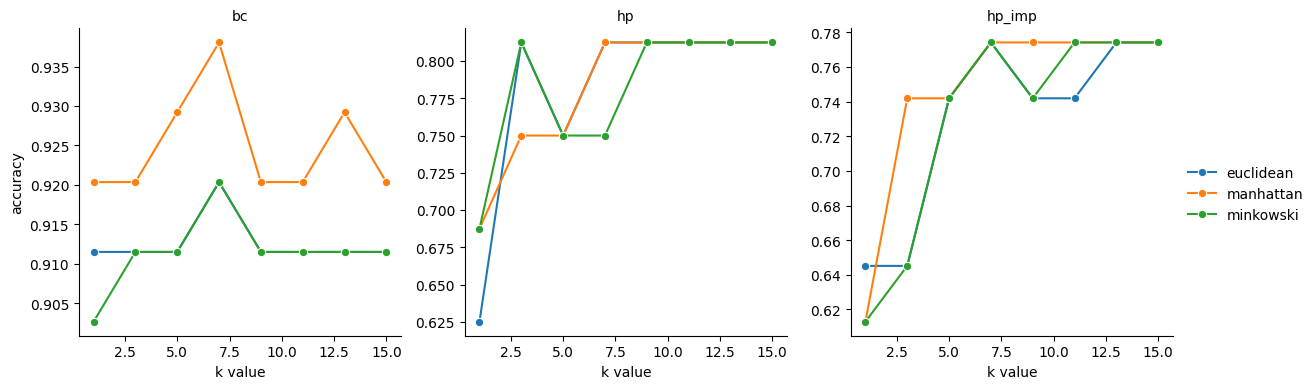

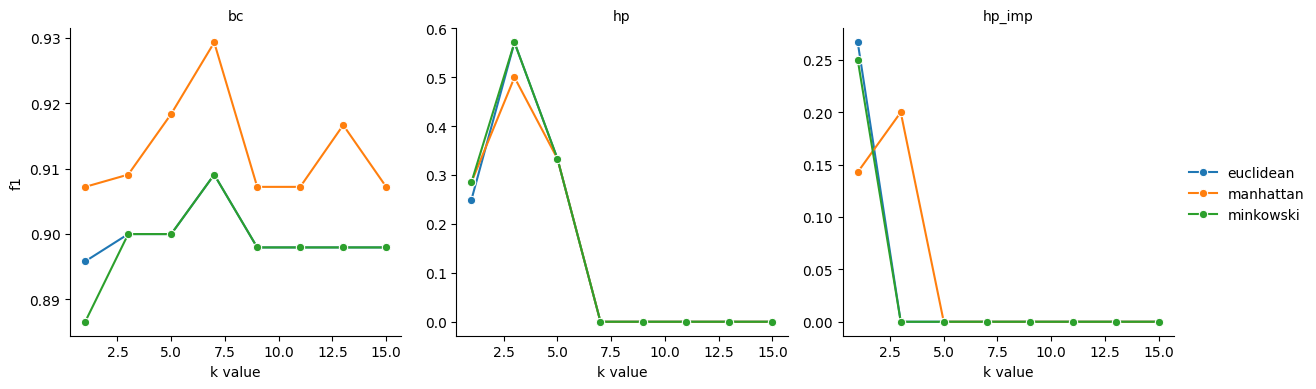

In [10]:
metrics_to_plot = ["accuracy", "f1"]

for metric in metrics_to_plot:
    g = sns.FacetGrid(df, col="dataset", height=4, sharey=False)
    g.map_dataframe(
        sns.lineplot,
        x="k_value",
        y=metric,
        hue="distance_function",
        marker="o"
    )
    g.add_legend()
    g.set_axis_labels("k value", metric)
    g.set_titles("{col_name}")
    plt.show()

In [12]:
def get_dataset_name(dataset):
    if dataset == "bc":
        return "Breast Cancer"
    elif dataset == "hp":
        return "Hepatitis"
    else:
        return "Hepatitis (Imputed)"

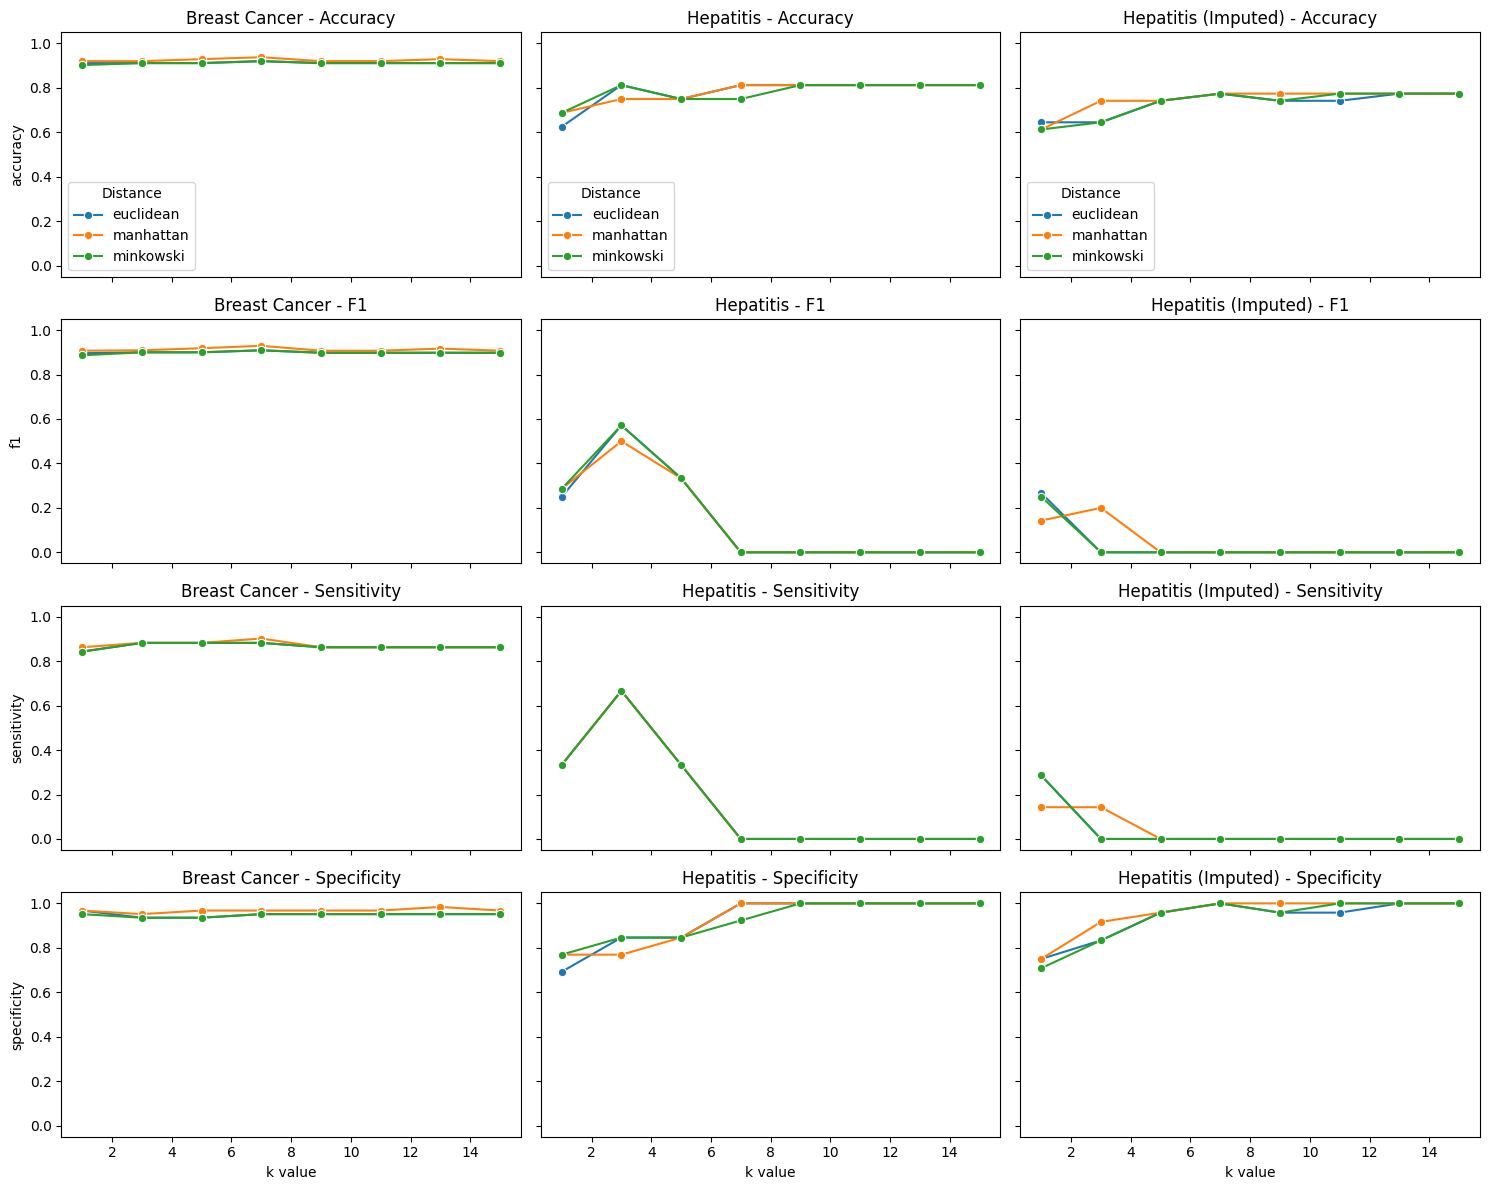

In [14]:
metrics_to_plot = ["accuracy", "f1", "sensitivity", "specificity"]
fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(15, 12), sharex=True, sharey=True)
datasets = df["dataset"].unique()

for i, metric in enumerate(metrics_to_plot):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        subset = df[df["dataset"] == dataset]
        sns.lineplot(
            data=subset, # type: ignore
            x="k_value",
            y=metric,
            hue="distance_function",
            marker="o",
            ax=ax
        )
        ax.set_title(f"{get_dataset_name(dataset)} - {metric.title()}")
        if i == len(metrics_to_plot)-1:
            ax.set_xlabel("k value")
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel(metric)
        else:
            ax.set_ylabel("")
        if i == 0:
            ax.legend(title="Distance")
        else:
            ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [15]:
best_bc_model = df[
    (df["dataset"] == "bc") &
    (df["distance_function"] == "manhattan") &
    (df["k_value"] == 7)
]
best_bc_model

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
11,bc,manhattan,7,0.938053,0.958333,0.901961,0.967742,0.032258,0.929293


In [16]:
best_hp_model = df[
    (df["dataset"] == "hp") &
    (df["distance_function"] == "minkowski") &
    (df["k_value"] == 3)
]
best_hp_model

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
41,hp,minkowski,3,0.8125,0.5,0.666667,0.846154,0.153846,0.571429


In [17]:
best_hp_imp_model = df[
    (df["dataset"] == "hp_imp") &
    (df["distance_function"] == "euclidean") &
    (df["k_value"] == 1)
]
best_hp_imp_model

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
48,hp_imp,euclidean,1,0.645161,0.25,0.285714,0.75,0.25,0.266667
